This notebook implements an agent that uses long term memory to keep track of the learning requirements.

In [1]:
import os, getpass
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

from dotenv import load_dotenv
load_dotenv()

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("AZURE_OPENAI_API_KEY")
_set_env("AZURE_OPENAI_ENDPOINT")

def fetch_LLM():
    return AzureChatOpenAI(
        model="gpt-4o", # replace with your model name from Azure Openai deployments
        api_version="2024-10-21",
        temperature=0
    )

Trustcall Extractor

In [2]:
from trustcall import create_extractor
from typing import TypedDict, List
from pydantic import BaseModel, Field


# Schema 
class UserProfile(BaseModel):
    """User profile schema with typed fields"""
    user_name: str = Field(description="The user's preferred name")
    interests: List[str] = Field(description="A list of the user's interests")

# Initialize the model
model = fetch_LLM()

# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[UserProfile],
    tool_choice="UserProfile"
)

# Instruction
system_msg = "Extract the user profile from the following conversation"

# Conversation
conversation = [HumanMessage(content="Hi, this is EAG Data Science group."), 
                AIMessage(content="Nice to meet you, EAG Data Science Group."), 
                HumanMessage(content="We love building AI agents!")]

# Invoke the extractor
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=system_msg)]+conversation})

In [3]:
for m in result["messages"]: 
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  UserProfile (call_GbFKe2GiK76zjlcjq0WPHpqm)
 Call ID: call_GbFKe2GiK76zjlcjq0WPHpqm
  Args:
    user_name: EAG Data Science Group
    interests: ['AI agents', 'data science']


In [4]:
schema = result["responses"]
schema

[UserProfile(user_name='EAG Data Science Group', interests=['AI agents', 'data science'])]

In [5]:
result["response_metadata"]

[{'id': 'call_GbFKe2GiK76zjlcjq0WPHpqm'}]

In [6]:
# Update the conversation
updated_conversation = [HumanMessage(content="Hi, this is EAG Data Science group."), 
                        AIMessage(content="Hello EAG Data Science group! Let me know how I can help!"), 
                        HumanMessage(content="We love building AI agents!"),
                        AIMessage(content="What kind of AI agents are you working on?"),
                        HumanMessage(content="We are focusing on natural language processing and computer vision."),]

# Update the instruction
system_msg = f"""Update the memory (JSON doc) to incorporate new information from the following conversation"""

# Invoke the extractor with the updated instruction and existing profile with the corresponding tool name (UserProfile)
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=system_msg)]+updated_conversation}, 
                                    {"existing": {"UserProfile": schema[0].model_dump()}})  

In [7]:
for m in result["messages"]: 
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  UserProfile (call_Fq0DwDrI7FmkSN5cHT92FkS1)
 Call ID: call_Fq0DwDrI7FmkSN5cHT92FkS1
  Args:
    user_name: EAG Data Science group
    interests: ['AI agents', 'natural language processing', 'computer vision']


In [8]:
updated_schema = result["responses"][0]
updated_schema.model_dump()

{'user_name': 'EAG Data Science group',
 'interests': ['AI agents', 'natural language processing', 'computer vision']}

In [9]:
from pydantic import BaseModel, Field
from trustcall import create_extractor
from langchain_openai import AzureChatOpenAI

class Memory(BaseModel):
    content: str = Field(description="The main content of the memory. For example: User/group expressed interest in learning about French.")

class MemoryCollection(BaseModel):
    memories: list[Memory] = Field(description="A list of memories about the user/group.")

# Inspect the tool calls made by Trustcall
class Spy:
    def __init__(self):
        self.called_tools = []

    def __call__(self, run):
        # Collect information about the tool calls made by the extractor.
        q = [run]
        while q:
            r = q.pop()
            if r.child_runs:
                q.extend(r.child_runs)
            if r.run_type == "chat_model":
                self.called_tools.append(
                    r.outputs["generations"][0][0]["message"]["kwargs"]["tool_calls"]
                )

# Initialize the spy
spy = Spy()

In [10]:

# Initialize the model
model = fetch_LLM()

# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True,
)

# Add the spy as a listener
trustcall_extractor_see_all_tool_calls = trustcall_extractor.with_listeners(on_end=spy)

In [11]:
# Instruction
instruction = """Extract memories from the following conversation:"""

# Conversation
conversation = [HumanMessage(content="Hi, this is EAG Data Science group."), 
                AIMessage(content="Hello EAG Data Science group! Let me know how I can help!"), 
                HumanMessage(content="We love building AI agents!")]

# Invoke the extractor
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=instruction)] + conversation})

In [12]:
# Messages contain the tool calls
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (call_sz73narhe2cJ9JbMgMxQG7g4)
 Call ID: call_sz73narhe2cJ9JbMgMxQG7g4
  Args:
    content: EAG Data Science group expressed their love for building AI agents.


In [13]:
# Responses contain the memories that adhere to the schema
for m in result["responses"]: 
    print(m)

content='EAG Data Science group expressed their love for building AI agents.'


In [14]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'call_sz73narhe2cJ9JbMgMxQG7g4'}


In [15]:
# We'll save existing memories, giving them an ID, key (tool name), and value
tool_name = "Memory"
existing_memories = [(str(i), tool_name, memory.model_dump()) for i, memory in enumerate(result["responses"])] if result["responses"] else None
existing_memories

[('0',
  'Memory',
  {'content': 'EAG Data Science group expressed their love for building AI agents.'})]

In [16]:
# Update the conversation
updated_conversation = [AIMessage(content="That's great, did you do after?"), 
                        HumanMessage(content="Our team have been building great chatbots, model finetuning, custom NER and other NLP activities too."),                        
                        AIMessage(content="That's impressive! What else is on your mind?"),
                        HumanMessage(content="We would love to explore multimodal generative capabilites!"),]

# Invoke the extractor with our updated conversation and existing memories
result = trustcall_extractor_see_all_tool_calls.invoke({"messages": updated_conversation, 
                                                        "existing": existing_memories})

In [17]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'call_2qncaEfJsw6KbNVyUgUT94V5'}


In [18]:
# Messages contain the tool calls
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (call_2qncaEfJsw6KbNVyUgUT94V5)
 Call ID: call_2qncaEfJsw6KbNVyUgUT94V5
  Args:
    content: EAG Data Science group expressed interest in exploring multimodal generative capabilities.


In [19]:
# Parsed responses
for m in result["responses"]:
    print(m)

content='EAG Data Science group expressed interest in exploring multimodal generative capabilities.'


In [20]:
# Inspect the tool calls made by Trustcall
spy.called_tools

[[{'name': 'Memory',
   'args': {'content': 'EAG Data Science group expressed interest in exploring multimodal generative capabilities.'},
   'id': 'call_2qncaEfJsw6KbNVyUgUT94V5',
   'type': 'tool_call'}]]

In [21]:
def extract_tool_info(tool_calls, schema_name="Memory"):
    """Extract information from tool calls for both patches and new memories.
    
    Args:
        tool_calls: List of tool calls from the model
        schema_name: Name of the schema tool (e.g., "Memory", "ToDo", "Profile")
    """

    # Initialize list of changes
    changes = []
    
    for call_group in tool_calls:
        for call in call_group:
            if call['name'] == 'PatchDoc':
                changes.append({
                    'type': 'update',
                    'doc_id': call['args']['json_doc_id'],
                    'planned_edits': call['args']['planned_edits'],
                    'value': call['args']['patches'][0]['value']
                })
            elif call['name'] == schema_name:
                changes.append({
                    'type': 'new',
                    'value': call['args']
                })

    # Format results as a single string
    result_parts = []
    for change in changes:
        if change['type'] == 'update':
            result_parts.append(
                f"Document {change['doc_id']} updated:\n"
                f"Plan: {change['planned_edits']}\n"
                f"Added content: {change['value']}"
            )
        else:
            result_parts.append(
                f"New {schema_name} created:\n"
                f"Content: {change['value']}"
            )
    
    return "\n\n".join(result_parts)

# Inspect spy.called_tools to see exactly what happened during the extraction
schema_name = "Memory"
changes = extract_tool_info(spy.called_tools, schema_name)
print(changes)

New Memory created:
Content: {'content': 'EAG Data Science group expressed interest in exploring multimodal generative capabilities.'}


#### Agent with Long Term Memory 

- We are going to implement an agent with long term memory capabilities. 
- Specifically it keeps track of the learning requirements.
- `user` node updates the profile while `todo` keeps track of the learning requirements
- `instructions` uses the provided feedback to modify the system message.

In [22]:
import uuid
from IPython.display import Image, display

from datetime import datetime
from trustcall import create_extractor
from typing import Optional
from pydantic import BaseModel, Field

from langchain_core.runnables import RunnableConfig
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, END, START
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore

from langchain_openai import AzureChatOpenAI

# Initialize the model
model = fetch_LLM()


In [23]:
from typing import TypedDict, Literal

# Update memory tool
class UpdateMemory(TypedDict):
    """ Decision on what memory type to update """
    update_type: Literal['user', 'todo', 'instructions']

    
# Chatbot instruction for choosing what to update and what tools to call 
MODEL_SYSTEM_MESSAGE = """You are a helpful chatbot. 

You are designed to be a companion to a user, helping them keep track of their ToDo list.

You have a long term memory which keeps track of three things:
1. The user's profile (general information about them) 
2. The user's ToDo list
3. General instructions for updating the ToDo list

Here is the current User Profile (may be empty if no information has been collected yet):
<user_profile>
{user_profile}
</user_profile>

Here is the current ToDo List (may be empty if no tasks have been added yet):
<todo>
{todo}
</todo>

Here are the current user-specified preferences for updating the ToDo list (may be empty if no preferences have been specified yet):
<instructions>
{instructions}
</instructions>

Here are your instructions for reasoning about the user's messages:

1. Reason carefully about the user's messages as presented below. 

2. Decide whether any of the your long-term memory should be updated:
- If personal information was provided about the user, update the user's profile by calling UpdateMemory tool with type `user`
- If tasks are mentioned, update the ToDo list by calling UpdateMemory tool with type `todo`
- If the user has specified preferences for how to update the ToDo list, update the instructions by calling UpdateMemory tool with type `instructions`

3. Tell the user that you have updated your memory, if appropriate:
- Do not tell the user you have updated the user's profile
- Tell the user them when you update the todo list
- Do not tell the user that you have updated instructions

4. Err on the side of updating the todo list. No need to ask for explicit permission.

5. Respond naturally to user user after a tool call was made to save memories, or if no tool call was made."""



# Trustcall instruction
TRUSTCALL_INSTRUCTION = """Reflect on following interaction. 

Use the provided tools to retain any necessary memories about the user. 

Use parallel tool calling to handle updates and insertions simultaneously.

System Time: {time}"""

In [24]:

# profile schema
class Profile(BaseModel):
    """This is the profile of the user you are chatting with"""
    name: Optional[str] = Field(description="The user's name", default=None)
    location: Optional[str] = Field(description="The user's location", default=None)
    job: Optional[str] = Field(description="The user's job", default=None)
    connections: list[str] = Field(
        description="Personal connection of the user, such as family members, friends, or coworkers",
        default_factory=list
    )
    interests: list[str] = Field(
        description="Interests that the user has", 
        default_factory=list
    )

# Create the Trustcall extractor for updating the user profile 
profile_extractor = create_extractor(
    model,
    tools=[Profile],
    tool_choice="Profile",
)

def update_profile(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("profile", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "Profile"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Invoke the extractor
    result = profile_extractor.invoke({"messages": updated_messages, 
                                         "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated profile", "tool_call_id":tool_calls[0]['id']}]}

In [25]:
# ToDo schema
class ToDo(BaseModel):
    task: str = Field(description="The learning requirement.")
    time_to_complete: Optional[int] = Field(description="Estimated time to complete the task (minutes).")
    deadline: Optional[datetime] = Field(
        description="When the task needs to be completed by (if applicable)",
        default=None
    )
    solutions: list[str] = Field(
        description="List of specific, actionable solutions (e.g., specific ideas, service providers, or concrete options relevant to completing the task)",
        min_items=1,
        default_factory=list
    )
    status: Literal["not started", "in progress", "done", "archived"] = Field(
        description="Current status of the task",
        default="not started"
    )



def update_todos(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("todo", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "ToDo"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # Merge the chat history and the instruction
    TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

    # Initialize the spy for visibility into the tool calls made by Trustcall
    spy = Spy()
    
    # Create the Trustcall extractor for updating the ToDo list 
    todo_extractor = create_extractor(
        model,
        tools=[ToDo],
        tool_choice=tool_name,
        enable_inserts=True
    ).with_listeners(on_end=spy)

    # Invoke the extractor
    result = todo_extractor.invoke({"messages": updated_messages, 
                                    "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )
    tool_calls = state['messages'][-1].tool_calls
    todo_update_msg = extract_tool_info(spy.called_tools, tool_name)
    return {"messages": [{"role": "tool", "content": todo_update_msg, "tool_call_id":tool_calls[0]['id']}]}


In [26]:
# Instructions for updating the ToDo list
CREATE_INSTRUCTIONS = """Reflect on the following interaction.

Based on this interaction, update your instructions for how to update ToDo list items. 

Use any feedback from the user to update how they like to have items added, etc.

Your current instructions are:

<current_instructions>
{current_instructions}
</current_instructions>"""

def update_instructions(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]
    
    namespace = ("instructions", user_id)

    existing_memory = store.get(namespace, "user_instructions")
        
    # Format the memory in the system prompt
    system_msg = CREATE_INSTRUCTIONS.format(current_instructions=existing_memory.value if existing_memory else None)
    new_memory = model.invoke([SystemMessage(content=system_msg)]+state['messages'][:-1] + [HumanMessage(content="Please update the instructions based on the conversation")])

    # Overwrite the existing memory in the store 
    key = "user_instructions"
    store.put(namespace, key, {"memory": new_memory.content})
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated instructions", "tool_call_id":tool_calls[0]['id']}]}

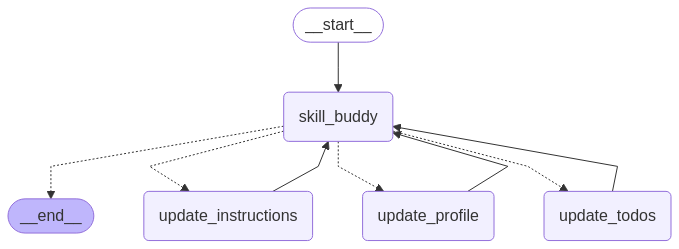

In [27]:
# Node definitions
def skill_buddy(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memories from the store and use them to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve profile memory from the store
    namespace = ("profile", user_id)
    memories = store.search(namespace)
    if memories:
        user_profile = memories[0].value
    else:
        user_profile = None

    # Retrieve task memory from the store
    namespace = ("todo", user_id)
    memories = store.search(namespace)
    todo = "\n".join(f"{mem.value}" for mem in memories)

    # Retrieve custom instructions
    namespace = ("instructions", user_id)
    memories = store.search(namespace)
    if memories:
        instructions = memories[0].value
    else:
        instructions = ""
    
    system_msg = MODEL_SYSTEM_MESSAGE.format(user_profile=user_profile, todo=todo, instructions=instructions)

    # Respond using memory as well as the chat history
    response = model.bind_tools([UpdateMemory], parallel_tool_calls=False).invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": [response]}


# Conditional edge
def route_message(state: MessagesState, config: RunnableConfig, store: BaseStore) -> Literal[END, "update_todos", "update_instructions", "update_profile"]:

    """Reflect on the memories and chat history to decide whether to update the memory collection."""
    message = state['messages'][-1]
    if len(message.tool_calls) ==0:
        return END
    else:
        tool_call = message.tool_calls[0]
        if tool_call['args']['update_type'] == "user":
            return "update_profile"
        elif tool_call['args']['update_type'] == "todo":
            return "update_todos"
        elif tool_call['args']['update_type'] == "instructions":
            return "update_instructions"
        else:
            raise ValueError

# Create the graph + all nodes
builder = StateGraph(MessagesState)

# Define the flow of the memory extraction process
builder.add_node(skill_buddy)
builder.add_node(update_todos)
builder.add_node(update_profile)
builder.add_node(update_instructions)
builder.add_edge(START, "skill_buddy")
builder.add_conditional_edges("skill_buddy", route_message)
builder.add_edge("update_todos", "skill_buddy")
builder.add_edge("update_profile", "skill_buddy")
builder.add_edge("update_instructions", "skill_buddy")

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# We compile the graph with the checkpointer and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

##### Update Profile

In [28]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "EAG DS"}}

# User input to create a profile memory
input_messages = [HumanMessage(content="This is EAG DS team. We are a lean team of data scientists with capabilities in classical ML, NLP, CV and Language Models.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

This is EAG DS team. We are a lean team of data scientists with capabilities in classical ML, NLP, CV and Language Models.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_HvPTATPC5B5cYbBlLPmpbILx)
 Call ID: call_HvPTATPC5B5cYbBlLPmpbILx
  Args:
    update_type: user
================================= Tool Message =================================

updated profile
================================== Ai Message ==================================

Got it! How can I assist your team today?


##### Update To-Do

In [29]:
# User input for a ToDo
input_messages = [HumanMessage(content="We plan to learn about implementations of patterns in agentic frameworks.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

We plan to learn about implementations of patterns in agentic frameworks.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_c7eDswJWeY36quQhN6IvIjFC)
 Call ID: call_c7eDswJWeY36quQhN6IvIjFC
  Args:
    update_type: todo
================================= Tool Message =================================

New ToDo created:
Content: {'task': 'Learn about implementations of patterns in agentic frameworks.', 'time_to_complete': 120, 'solutions': ["Explore documentation and tutorials of agentic frameworks like LangChain, Haystack, or OpenAI's tools.", 'Review case studies or examples of agentic framework implementations.', 'Experiment with building a small project using an agentic framework to understand patterns.'], 'status': 'not started'}
================================== Ai Message ==================================

I've added your plan to learn

##### Update Instructions

In [30]:
# User input to update instructions for creating ToDos
# input_messages = [HumanMessage(content="When creating or updating ToDo items, include specific resource provider names as well.")]
input_messages = [HumanMessage(content="When creating or updating ToDo items, place any Microsoft specific resources on the top.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

When creating or updating ToDo items, place any Microsoft specific resources on the top.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_RIMimgpZ63GA6SEgolvH6UOs)
 Call ID: call_RIMimgpZ63GA6SEgolvH6UOs
  Args:
    update_type: instructions
================================= Tool Message =================================

updated instructions
================================== Ai Message ==================================

Understood! I'll prioritize Microsoft-specific resources at the top when creating or updating your ToDo items. Let me know if there's anything else you'd like to adjust.


In [31]:
# Check for updated instructions
user_id = "EAG DS"

# Search 
for memory in across_thread_memory.search(("instructions", user_id)):
    print(memory.value)

{'memory': "Here are the updated instructions for creating or updating ToDo list items:\n\n<current_instructions>\n1. When creating or updating ToDo items, prioritize Microsoft-specific resources by placing them at the top of the list of solutions or resources.\n2. Include a clear task description, estimated time to complete, potential solutions or resources, and the current status of the task.\n3. Ensure the task aligns with the team's focus areas, such as classical ML, NLP, CV, Language Models, or agentic frameworks.\n</current_instructions>\n\nLet me know if there's anything else you'd like to refine!"}


In [32]:
# User input for a ToDo
input_messages = [HumanMessage(content="Need to learn about the recent inference optimization techniques. Could take 4 hours.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Need to learn about the recent inference optimization techniques. Could take 4 hours.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_jM9t5hvhYmd70W9l48jaAz0I)
 Call ID: call_jM9t5hvhYmd70W9l48jaAz0I
  Args:
    update_type: todo


2 validation errors for ToDo
task
  Field required [type=missing, input_value={'update_type': 'todo'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.11/v/missing
time_to_complete
  Field required [type=missing, input_value={'update_type': 'todo'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.11/v/missing


================================= Tool Message =================================

New ToDo created:
Content: {'task': 'Learn about the recent inference optimization techniques.', 'time_to_complete': 240, 'solutions': ['Explore Microsoft-specific resources like Azure ML documentation or related optimization tools.', 'Review recent research papers or blogs on inference optimization.', 'Experiment with implementing optimization techniques in a small project.'], 'status': 'not started'}
================================== Ai Message ==================================

I've added the task to learn about recent inference optimization techniques to your ToDo list, with an estimated time of 4 hours. Let me know if there's anything else you'd like to include!


In [33]:
# User input for a ToDo
input_messages = [HumanMessage(content="Need to learn Model Context Protocol implementations. Estimated time is 5 hours.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()
    

================================ Human Message =================================

Need to learn Model Context Protocol implementations. Estimated time is 5 hours.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_Mwh4eYWHUH87KuYtjLLedz0O)
 Call ID: call_Mwh4eYWHUH87KuYtjLLedz0O
  Args:
    update_type: todo
================================= Tool Message =================================

New ToDo created:
Content: {'task': 'Learn Model Context Protocol implementations.', 'time_to_complete': 300, 'solutions': ['Explore Microsoft-specific resources or documentation related to Model Context Protocol.', 'Review open-source implementations or libraries supporting Model Context Protocol.', "Experiment with implementing a small project to understand the protocol's practical applications."], 'status': 'not started'}
================================== Ai Message ==================================

I've added the task to learn about

In [34]:
# Namespace for the memory to save
user_id = "EAG DS"

# Search 
for memory in across_thread_memory.search(("todo", user_id)):
    print(memory.value)

{'task': 'Learn about implementations of patterns in agentic frameworks.', 'time_to_complete': 120, 'deadline': None, 'solutions': ["Explore documentation and tutorials of agentic frameworks like LangChain, Haystack, or OpenAI's tools.", 'Review case studies or examples of agentic framework implementations.', 'Experiment with building a small project using an agentic framework to understand patterns.'], 'status': 'not started'}
{'task': 'Learn about the recent inference optimization techniques.', 'time_to_complete': 240, 'deadline': None, 'solutions': ['Explore Microsoft-specific resources like Azure ML documentation or related optimization tools.', 'Review recent research papers or blogs on inference optimization.', 'Experiment with implementing optimization techniques in a small project.'], 'status': 'not started'}
{'task': 'Learn Model Context Protocol implementations.', 'time_to_complete': 300, 'deadline': None, 'solutions': ['Explore Microsoft-specific resources or documentation r

##### Update an existing To-Do

In [35]:
# User input to update an existing ToDo
input_messages = [HumanMessage(content="Need to learn the inference optimization techniques very specific to SLMs.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Need to learn the inference optimization techniques very specific to SLMs.
================================== Ai Message ==================================
Tool Calls:
  UpdateMemory (call_ZWYiC6Tt7XB4R68MLuhbFB2M)
 Call ID: call_ZWYiC6Tt7XB4R68MLuhbFB2M
  Args:
    update_type: todo
================================= Tool Message =================================

Document 5af4aa8b-bd5c-408e-aaa3-63814f8a522d updated:
Plan: Update the solutions to prioritize Microsoft-specific resources and include SLM-specific inference optimization techniques.
Added content: ['Explore Microsoft-specific resources like Azure ML documentation or related optimization tools for SLMs.', 'Review recent research papers or blogs on inference optimization specific to SLMs.', 'Experiment with implementing optimization techniques for SLMs in a small project.']
================================== Ai Message =========================

In [36]:
# Namespace for the memory to save
user_id = "EAG DS"

# Search 
for memory in across_thread_memory.search(("todo", user_id)):
    print(memory.value)

{'task': 'Learn about implementations of patterns in agentic frameworks.', 'time_to_complete': 120, 'deadline': None, 'solutions': ["Explore documentation and tutorials of agentic frameworks like LangChain, Haystack, or OpenAI's tools.", 'Review case studies or examples of agentic framework implementations.', 'Experiment with building a small project using an agentic framework to understand patterns.'], 'status': 'not started'}
{'task': 'Learn about the recent inference optimization techniques.', 'time_to_complete': 240, 'deadline': None, 'solutions': ['Explore Microsoft-specific resources like Azure ML documentation or related optimization tools for SLMs.', 'Review recent research papers or blogs on inference optimization specific to SLMs.', 'Experiment with implementing optimization techniques for SLMs in a small project.'], 'status': 'not started'}
{'task': 'Learn Model Context Protocol implementations.', 'time_to_complete': 300, 'deadline': None, 'solutions': ['Explore Microsoft-sp

#### New Session

Now we can create a new thread.

This creates a new session. 

Profile, ToDos, and Instructions saved to long-term memory are accessed. 

In [37]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "2", "user_id": "EAG DS"}}

# Chat with the chatbot
input_messages = [HumanMessage(content="Have 5 hours of time, what can be learnt?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Have 3 hours of time, what can be learnt?
================================== Ai Message ==================================

You have 3 hours available, which is 180 minutes. Based on your ToDo list, here are some options:

1. **Learn about implementations of patterns in agentic frameworks** (120 minutes):
   - You can complete this task and still have 60 minutes left for something else.

2. **Learn about the recent inference optimization techniques** (240 minutes):
   - You can start this task and make significant progress, but you won't be able to finish it in 3 hours.

3. **Learn Model Context Protocol implementations** (300 minutes):
   - You can start this task and make good progress, but it will require additional time to complete.

Would you like to focus on completing the first task or start one of the longer ones? Let me know!


In [38]:
# Chat with the chatbot
input_messages = [HumanMessage(content="Yes, give me some options to call for pruning.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Yes, give me some options to call for pruning.
================================== Ai Message ==================================

For pruning techniques, especially in the context of inference optimization or model compression, here are some options you can explore:

### 1. **Structured Pruning**
   - Remove entire neurons, channels, or layers based on their importance.
   - Tools/Resources:
     - Microsoft-specific: Explore Azure ML's model optimization tools.
     - General: PyTorch's `torch.nn.utils.prune` module or TensorFlow Model Optimization Toolkit.

### 2. **Unstructured Pruning**
   - Remove individual weights based on their magnitude (e.g., weights close to zero).
   - Tools/Resources:
     - PyTorch's `torch.nn.utils.prune` for unstructured pruning.
     - Research papers like "Lottery Ticket Hypothesis" for insights.

### 3. **Quantization-Aware Pruning**
   - Combine pruning with quantizatio